# Counting Molecules — Stage 2: Binarisation

This notebook converts mean-corrected STM images into binary masks that separate molecules (foreground) from the substrate (background). The resulting masks feed into blob detection in `03_blob_detection.ipynb`.

The approach uses **Otsu thresholding** to automatically find the intensity cutoff between molecules and background, followed by **morphological closing** to fill small gaps within molecule footprints, and **border clearing** to drop molecules that are only partially visible at image edges.

**Author:** Stephanie Wainaina  
**Project type:** Monash data science studio  
**Stack:** Python, scikit-image, NumPy, Matplotlib

> See the repo README for full project context. Data files are not included in this repository (proprietary research data), so cell outputs are saved for reference.

## 1. Setup

This notebook is self-contained: it reloads the four STM images from raw files and re-applies the mean-field correction from Stage 1, so it can be run independently. If you've already executed `01_read_stm_images.ipynb` in the same session, the loader functions and corrected arrays would also be available.

In [2]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Workaround: nanonispy v1.1.0 uses np.float which was removed in NumPy 1.20+
if not hasattr(np, "float"):
    np.float = float

import nanonispy as nap
from skimage.filters import threshold_otsu
from skimage.morphology import closing, square
from skimage.segmentation import clear_border

DATA_DIR =r'C:\Users\steph\OneDrive\Desktop\github_rebuild\counting_molecules\Counting-Molecules\data' 

In [5]:
np.int = int

## 2. Reload and pre-process the four images

We re-use the same loader functions and mean-field removal from Notebook 01.

In [3]:
def load_txt_image(filepath):
    """Load an STM image stored as a plain text array."""
    return np.loadtxt(filepath)


def load_pickle_image(filepath):
    """Load an STM image from a pickled dictionary."""
    with open(filepath, "rb") as f:
        data = pickle.load(f)
    return data["image"], data.get("rescale", None)


def load_sxm_image(filepath):
    """Load an STM image from a Nanonis .sxm scan file."""
    scan = nap.read.Scan(filepath)
    image = scan.signals["Z"]["forward"]
    if scan.header["scan_dir"] == "down":
        image = np.flipud(image)
    image[np.isnan(image)] = np.mean(image[~np.isnan(image)])
    rescale = scan.header["scan_range"] / scan.header["scan_pixels"]
    return image, rescale


def remove_mean_field(image):
    """Remove the slowly-varying mean-field artefact from an STM image."""
    corrected = image.copy().astype(float)
    corrected = corrected - np.mean(corrected, axis=0)[np.newaxis, :]
    corrected = corrected - np.mean(corrected, axis=1)[:, np.newaxis]
    return corrected

In [6]:
# Load all four raw images
image_a = load_txt_image(os.path.join(DATA_DIR, "1705_6.txt"))
image_b, _ = load_pickle_image(os.path.join(DATA_DIR, "111_test_data.p"))
image_c, _ = load_sxm_image(os.path.join(DATA_DIR, "Ag111_APT_007.sxm"))
image_d, _ = load_sxm_image(os.path.join(DATA_DIR, "180509_18-16-48_SPM001.sxm"))

# Apply mean-field correction
image_a_corrected = remove_mean_field(image_a)
image_b_corrected = remove_mean_field(image_b)
image_c_corrected = remove_mean_field(image_c)
image_d_corrected = remove_mean_field(image_d)

# Bundle into a dict for clean iteration
corrected_images = {
    "Image A (.txt)": image_a_corrected,
    "Image B (.p)": image_b_corrected,
    "Image C (.sxm)": image_c_corrected,
    "Image D (.sxm)": image_d_corrected,
}

print("Loaded and corrected:")
for name, img in corrected_images.items():
    print(f"  {name}: shape {img.shape}, range [{img.min():.3f}, {img.max():.3f}]")

Loaded and corrected:
  Image A (.txt): shape (556, 512), range [-0.000, 0.000]
  Image B (.p): shape (512, 512), range [-0.000, 0.000]
  Image C (.sxm): shape (1024, 1024), range [-0.000, 0.000]
  Image D (.sxm): shape (768, 768), range [-0.000, 0.000]


## 3. The binarisation problem

To count molecules, we need to separate them from the substrate. A binary mask, with True where a molecule sits and False elsewhere, is the cleanest representation for downstream blob detection.

The challenge: pixel intensities aren't directly meaningful. Different STM scans have different brightness ranges depending on tip condition, scan rate, and substrate. We can't hand-pick a single threshold value that works across all four images. We need an automatic method.

**Otsu's method** solves this by finding the threshold that maximises the variance *between* the foreground and background pixel classes. It's parameter-free and works directly on the corrected pixel histogram.

## 4. A single binarisation function

Combining Otsu thresholding, morphological closing (to fill 1-2 pixel gaps inside molecules), and border clearing (to drop molecules cut off at image edges) into one reusable function.

In [7]:
def binarise_stm_image(image, closing_size=3):
    """Convert a mean-corrected STM image into a binary mask of molecules.

    Uses Otsu thresholding to find the intensity cutoff, applies a small
    morphological closing to fill internal gaps within molecule footprints,
    and clears any molecules touching the image border.

    Parameters
    ----------
    image : np.ndarray
        Mean-corrected 2D STM image.
    closing_size : int, optional
        Side length of the structuring element used for morphological closing.
        Default 3.

    Returns
    -------
    np.ndarray (bool)
        Binary mask: True where molecules are, False elsewhere.
    """
    # 1. Otsu thresholding: automatically pick the intensity cutoff
    threshold = threshold_otsu(image)
    binary = image > threshold

    # 2. Morphological closing: fill small internal gaps
    binary = closing(binary, square(closing_size))

    # 3. Drop molecules that touch the image border (only partially visible)
    binary = clear_border(binary)

    return binary

## 5. Apply to all four images

Same function, no per-image parameter tuning. The Otsu method picks its own threshold for each image based on the pixel intensity distribution.

In [8]:
binarised_images = {
    name: binarise_stm_image(img) for name, img in corrected_images.items()
}

# Sanity check: what fraction of each image is now flagged as "molecule"?
print("Fraction of pixels classified as molecule:")
for name, mask in binarised_images.items():
    fraction = mask.sum() / mask.size
    print(f"  {name}: {fraction:.1%}")

Fraction of pixels classified as molecule:
  Image A (.txt): 0.1%
  Image B (.p): 5.9%
  Image C (.sxm): 11.1%
  Image D (.sxm): 18.8%


## 6. Visualise: raw → corrected → binarised

A four-column view per image, showing the full pipeline so far: the raw scan, the mean-corrected version, a single horizontal slice (to show where the Otsu threshold lands relative to the intensity distribution), and the final binary mask.

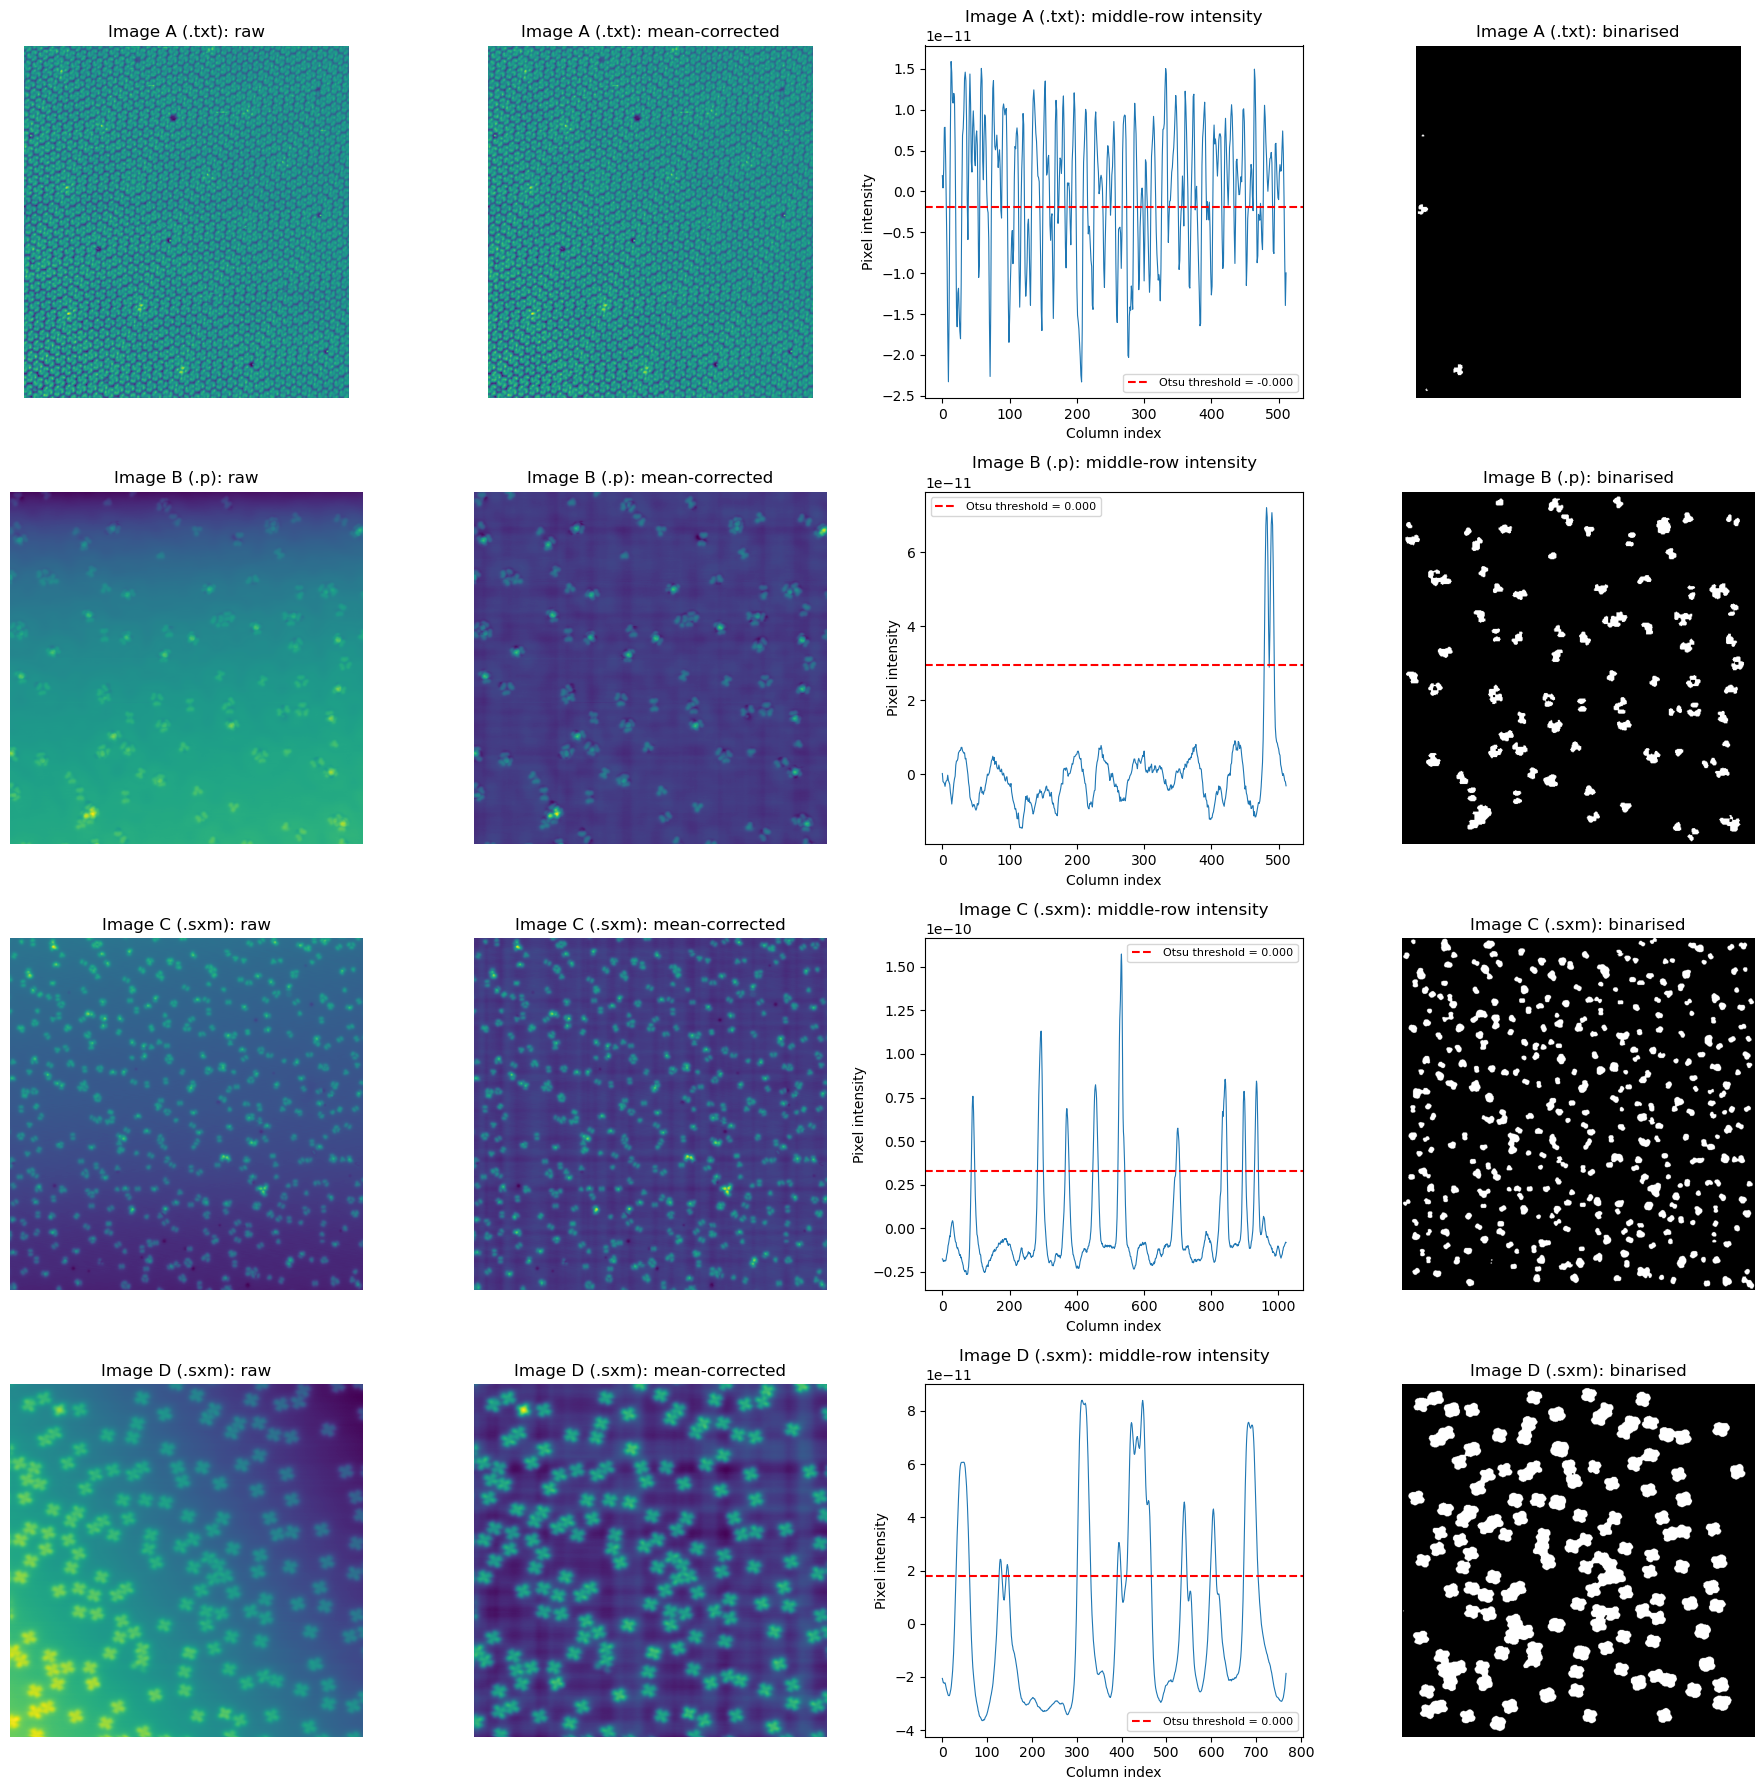

In [9]:
raw_images = {
    "Image A (.txt)": image_a,
    "Image B (.p)": image_b,
    "Image C (.sxm)": image_c,
    "Image D (.sxm)": image_d,
}

fig, axes = plt.subplots(4, 4, figsize=(18, 18))

for row_idx, (name, raw) in enumerate(raw_images.items()):
    corrected = corrected_images[name]
    mask = binarised_images[name]
    threshold = threshold_otsu(corrected)

    # Column 1: raw image
    axes[row_idx, 0].imshow(raw, cmap="viridis")
    axes[row_idx, 0].set_title(f"{name}: raw")
    axes[row_idx, 0].axis("off")

    # Column 2: mean-corrected
    axes[row_idx, 1].imshow(corrected, cmap="viridis")
    axes[row_idx, 1].set_title(f"{name}: mean-corrected")
    axes[row_idx, 1].axis("off")

    # Column 3: middle-row intensity slice with the Otsu threshold marked
    mid_row = corrected[corrected.shape[0] // 2]
    axes[row_idx, 2].plot(mid_row, linewidth=0.8)
    axes[row_idx, 2].axhline(threshold, color="red", linestyle="--", label=f"Otsu threshold = {threshold:.3f}")
    axes[row_idx, 2].set_xlabel("Column index")
    axes[row_idx, 2].set_ylabel("Pixel intensity")
    axes[row_idx, 2].set_title(f"{name}: middle-row intensity")
    axes[row_idx, 2].legend(fontsize=8)

    # Column 4: final binary mask
    axes[row_idx, 3].imshow(mask, cmap="gray")
    axes[row_idx, 3].set_title(f"{name}: binarised")
    axes[row_idx, 3].axis("off")

plt.tight_layout()
plt.show()

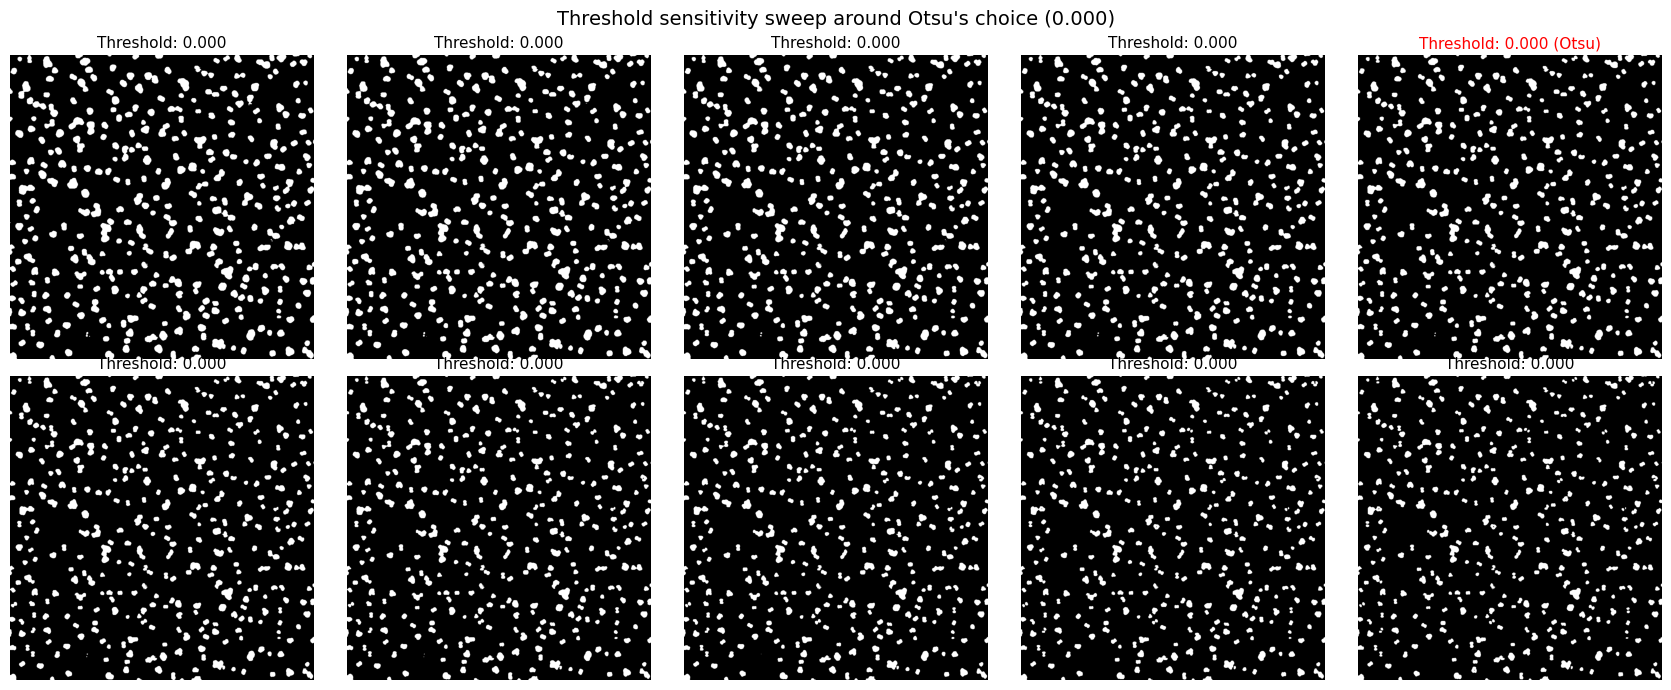

In [13]:
def threshold_checker(image, n_thresholds=10):
    """Sweep over candidate thresholds and visualise the resulting binary masks.
    
    Sweeps from 50% to 150% of the Otsu-chosen threshold. Useful for verifying
    that the automatic threshold is a sensible choice and for understanding
    how sensitive the binarisation is to small threshold changes.

    Parameters
    ----------
    image : np.ndarray
        Mean-corrected 2D STM image.
    n_thresholds : int, optional
        Number of threshold values to try. Default 10.
    """
    otsu = threshold_otsu(image)
    thresholds = np.linspace(otsu * 0.5, otsu * 1.5, n_thresholds)

    n_cols = 5
    n_rows = (n_thresholds + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 3.5 * n_rows))

    for n, ax in enumerate(axes.flatten()):
        if n < n_thresholds:
            mask = image > thresholds[n]
            ax.imshow(mask, cmap="gray")
            # Highlight the threshold closest to Otsu's choice
            is_otsu = abs(thresholds[n] - otsu) == min(abs(t - otsu) for t in thresholds)
            title = f"Threshold: {thresholds[n]:.3f}"
            if is_otsu:
                title += " (Otsu)"
            ax.set_title(title, fontsize=11, color=("red" if is_otsu else "black"))
        ax.axis("off")

    fig.suptitle(f"Threshold sensitivity sweep around Otsu's choice ({otsu:.3f})", fontsize=14)
    plt.tight_layout()
    plt.show()


# Run on Image C, which has the most visible mean-field artefact
threshold_checker(corrected_images["Image C (.sxm)"])

## 7. Sanity check on edge cases

Two things worth verifying before handing the masks off to blob detection:

1. The masks shouldn't have any large connected blobs touching the image border (the `clear_border` step should have removed those).
2. The masks shouldn't be empty (which would mean Otsu picked a bad threshold).

In [10]:
print("Edge-case checks on each binary mask:")
for name, mask in binarised_images.items():
    border_pixels = (
        mask[0, :].sum() + mask[-1, :].sum() +
        mask[:, 0].sum() + mask[:, -1].sum()
    )
    total_molecule_pixels = mask.sum()
    print(f"  {name}:")
    print(f"    total molecule pixels:  {total_molecule_pixels:>8,}")
    print(f"    pixels on image border: {border_pixels:>8,}  (should be 0)")
    print(f"    mask is empty?          {total_molecule_pixels == 0}")

Edge-case checks on each binary mask:
  Image A (.txt):
    total molecule pixels:       340
    pixels on image border:        0  (should be 0)
    mask is empty?          False
  Image B (.p):
    total molecule pixels:    15,354
    pixels on image border:        0  (should be 0)
    mask is empty?          False
  Image C (.sxm):
    total molecule pixels:   116,897
    pixels on image border:        0  (should be 0)
    mask is empty?          False
  Image D (.sxm):
    total molecule pixels:   110,858
    pixels on image border:        0  (should be 0)
    mask is empty?          False


## Summary

The binarisation stage is now reproducible across all four images with a single function call. Key design decisions:

1. **Otsu thresholding** (parameter-free) handles the different intensity ranges of the four images without manual tuning. The pipeline generalises beyond the four examples shown here.
2. **Morphological closing** with a 3x3 structuring element fills small internal gaps without merging neighbouring molecules.
3. **Border clearing** drops partial molecules at image edges, so downstream counting doesn't include incomplete shapes.

The four binary masks are stored in `binarised_images` and are ready for blob detection in `03_blob_detection.ipynb`.